# 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime

pd.set_option('display.max_columns', None)

# 2. Load the Dataset

In [2]:
df = pd.read_csv(r'C:\Users\hp\Documents\Progree Internship Tasks or Project Documents\Task 3\Task 3 Documents\Sample_Superstore.csv', encoding='latin1')

print("Shape:", df.shape)
df.head()

Shape: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# 3. Initial Data Inspection

In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

# 4. Clean & Fix Data Types

In [4]:
# Convert date columns from string to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Keep Postal Code as string (avoid losing leading zeros)
df['Postal Code'] = df['Postal Code'].astype(str)

# Confirm changes
df.dtypes

Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code              object
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object

# 5. Set the Reference Date for Recency

In [5]:
# Recency needs a fixed reference point — we use one day after the last order in the dataset
reference_date = df['Order Date'].max() + pd.Timedelta(days=1)
print("Reference date for Recency calculation:", reference_date)

Reference date for Recency calculation: 2017-12-31 00:00:00


# 6. Compute RFM Metrics (Group by Customer)

In [6]:
rfm = df.groupby(['Customer ID', 'Customer Name']).agg(
    Recency=('Order Date', lambda x: (reference_date - x.max()).days),
    Frequency=('Order ID', 'nunique'),
    Monetary=('Sales', 'sum')
).reset_index()

rfm.head()

,Customer ID,Customer Name,Recency,Frequency,Monetary
0,AA-10315,Alex Avila,185,5,5563.560
1,AA-10375,Allen Armold,20,9,1056.390
2,AA-10480,Andrew Allen,260,4,1790.512
3,AA-10645,Anna Andreadi,56,6,5086.935
4,AB-10015,Aaron Bergman,416,3,886.156


# 7. Score Each Metric (1-5 Scale using Quantiles)

In [7]:
# Recency: lower value (more recent) = better score, so scoring is reversed
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1]).astype(int)

# Frequency & Monetary: higher value = better score
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm.head()

,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5
1,AA-10375,Allen Armold,20,9,1056.390,5,5,2
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3
3,AA-10645,Anna Andreadi,56,6,5086.935,3,3,5
4,AB-10015,Aaron Bergman,416,3,886.156,1,1,1


# 8. Combine into an RFM Score

In [8]:
rfm['RFM_Score'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score_Sum'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

rfm.head()

,Customer ID,Customer Name,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Score_Sum
0,AA-10315,Alex Avila,185,5,5563.560,2,2,5,225,9
1,AA-10375,Allen Armold,20,9,1056.390,5,5,2,552,12
2,AA-10480,Andrew Allen,260,4,1790.512,1,1,3,113,5
3,AA-10645,Anna Andreadi,56,6,5086.935,3,3,5,335,11
4,AB-10015,Aaron Bergman,416,3,886.156,1,1,1,111,3


# 9. Assign Customer Segments

In [9]:
def segment_customer(row):
    if row['RFM_Score_Sum'] >= 13:
        return 'Champions'
    elif row['RFM_Score_Sum'] >= 10:
        return 'Loyal Customers'
    elif row['RFM_Score_Sum'] >= 7:
        return 'Potential Loyalist'
    elif row['RFM_Score_Sum'] >= 5:
        return 'At Risk'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm['Segment'].value_counts()

Segment
Loyal Customers       254
Potential Loyalist    219
Champions             124
At Risk               116
Lost                   80
Name: count, dtype: int64

# 10. Visualize Segment Distribution (Quick Sanity Check)

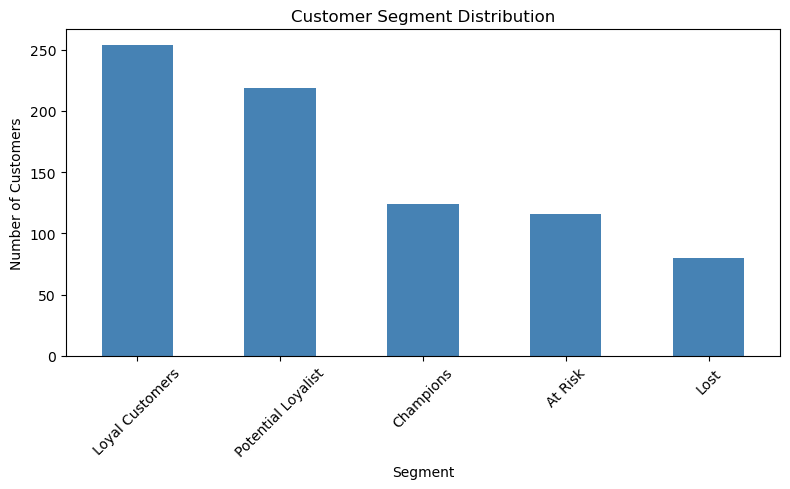

In [10]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(kind='bar', figsize=(8,5), color='steelblue')
plt.title('Customer Segment Distribution')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 11. Export Clean Files for Power BI

In [11]:
# Export customer-level RFM table
rfm.to_csv('customer_rfm_segments.csv', index=False)

# Export cleaned transaction-level data (needed later for cohort trends & geo map in Power BI)
df.to_csv('cleaned_superstore_transactions.csv', index=False)

print("Files exported successfully.")

Files exported successfully.
